# Pipeline de Preparação de Dados — Macro 3
Passos: seleção estatística de preditores, encoding, scaling, imputação, classes raras, data leakage.

## 1. Carregar e Filtrar Dados

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Tenta treino.csv; fallback para amostra
import os
DATA_PATH = 'treino.csv' if os.path.exists('treino.csv') else 'amostra_2025.xlsx'
if DATA_PATH.endswith('.csv'):
    df_raw = pd.read_csv(DATA_PATH)
else:
    df_raw = pd.read_excel(DATA_PATH)
print(f'Fonte: {DATA_PATH} | Shape: {df_raw.shape}')


Fonte: amostra_2025.xlsx | Shape: (500, 94)


In [2]:
# Decodificar idade
df_raw['nu_str'] = df_raw['NU_IDADE_N'].astype(str).str.zfill(4)
df_raw['idade_unid'] = pd.to_numeric(df_raw['nu_str'].str[0], errors='coerce')
df_raw['idade_val']  = pd.to_numeric(df_raw['nu_str'].str[1:], errors='coerce')
df_raw['idade_anos'] = np.where(df_raw['idade_unid']==4, df_raw['idade_val'],
                        np.where(df_raw['idade_unid']==3, (df_raw['idade_val']/12).round(),
                        np.where(df_raw['idade_unid']==2, (df_raw['idade_val']/365).round(), np.nan)))

# Filtros alinhados com data-prep.py
df = df_raw.copy()
df = df[df['idade_anos'] >= 18]
df = df[df['FORMA'].astype(str) == '1']
df = df[df['TRATAMENTO'].astype(str) != '6']
df = df[df['SITUA_ENCE'].isin([1.0, 2.0])]

# Variável-alvo
df['ltfu'] = df['SITUA_ENCE'].map({1.0: 0, 2.0: 1}).astype(int)
print(f'Após filtros: {df.shape}')
print(f'ltfu=1: {df["ltfu"].sum()} | ltfu=0: {(df["ltfu"]==0).sum()}')


Após filtros: (166, 99)
ltfu=1: 84 | ltfu=0: 82


## 2. Remover Colunas com Data Leakage e 100% Nulas

In [3]:
# Drop 100% nulos
null_pct = df.isnull().mean()
drop_null = null_pct[null_pct == 1.0].index.tolist()
print(f'Drop 100% nulos ({len(drop_null)}): {drop_null}')

# Data leakage: revelam o desfecho
drop_leakage = ['SITUA_ENCE','DT_ENCERRA','SITUA_9_M','SITUA_12_M',
                 'BACILOSC_1','BACILOSC_2','BACILOSC_3','BACILOSC_4','BACILOSC_5','BACILOSC_6',
                 'BAC_APOS_6','TRANSF','UF_TRANSF','MUN_TRANSF']

# Campos administrativos sem valor preditivo
drop_admin = ['TP_NOT','ID_AGRAVO','NU_ANO','DT_DIGITA','DT_TRANSUS','DT_TRANSDM',
               'DT_TRANSSM','DT_TRANSRM','DT_TRANSRS','DT_TRANSSE','NDUPLIC_N',
               'IN_VINCULA','FLXRECEBI','MIGRADO_W','CS_FLXRET','NU_IDADE_N',
               'nu_str','idade_unid','idade_val']

drop_all = list(set(drop_null + drop_leakage + drop_admin))
drop_all = [c for c in drop_all if c in df.columns]
df = df.drop(columns=drop_all)
print(f'Colunas restantes: {df.shape[1]} (removidas: {len(drop_all)})')


Drop 100% nulos (20): ['DT_TRANSRM', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W', 'ID_OCUPA_N', 'INSTITUCIO', 'TESTE_TUBE', 'EXTRAPU2_N', 'BACILOS_E2', 'RIFAMPICIN', 'ISONIAZIDA', 'ETAMBUTOL', 'ESTREPTOMI', 'PIRAZINAMI', 'ETIONAMIDA', 'OUTRAS', 'DOENCA_TRA', 'DT_MUDANCA', 'SITUA_9_M', 'SITUA_12_M']
Colunas restantes: 52 (removidas: 47)


## 3. Feature Engineering

In [12]:
# Feature: reingresso apos abandono anterior
df['reingresso'] = (df['TRATAMENTO'].astype(str) == '3').astype(int)
print('reingresso=1:', df['reingresso'].sum())

# Feature: atraso entre notificacao e inicio do tratamento
for col in ['DT_NOTIFIC','DT_INIC_TR','DT_DIAG']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col].astype(str), format='%Y%m%d', errors='coerce')

if 'DT_INIC_TR' in df.columns and 'DT_NOTIFIC' in df.columns:
    df['dias_notif_trat'] = (df['DT_INIC_TR'] - df['DT_NOTIFIC']).dt.days
    df['dias_notif_trat'] = df['dias_notif_trat'].clip(0, 365)
    print('dias_notif_trat: media=', round(df['dias_notif_trat'].mean(), 1))

# Tratar colunas de data como numericas (ano, mes) ou remover
date_cols = [c for c in df.columns if df[c].dtype == 'datetime64[ns]']
df = df.drop(columns=date_cols)
print('Colunas de data removidas:', date_cols)


reingresso=1: 72
Colunas de data removidas: []


## 4. Classificar Colunas por Tipo de Encoding

In [13]:
TARGET = 'ltfu'
EXCLUDE = [TARGET]

# Numericas continuas
NUM_COLS = ['idade_anos','NU_CONTATO','dias_notif_trat']
NUM_COLS = [c for c in NUM_COLS if c in df.columns]

# Ordinal: escolaridade
ORD_COLS = ['CS_ESCOL_N']
ORD_COLS = [c for c in ORD_COLS if c in df.columns]

# Binarias com 9=ignorado -> tratar 9 como NaN e depois OneHot
BIN_COLS = ['CS_SEXO','AGRAVAIDS','AGRAVALCOO','AGRAVDIABE','AGRAVDOENC',
             'AGRAVDROGA','AGRAVTABAC','POP_RUA','POP_LIBER','POP_IMIG',
             'POP_SAUDE','BENEF_GOV','reingresso']
BIN_COLS = [c for c in BIN_COLS if c in df.columns]

# Nominais multiclasse
NOM_COLS = ['CS_RACA','HIV','BACILOSC_E','CULTURA_ES','FORMA','TRATAMENTO',
             'TEST_MOLEC','RAIO_TORA','TESTE_TUBE']
NOM_COLS = [c for c in NOM_COLS if c in df.columns]

print(f'Numericas: {NUM_COLS}')
print(f'Ordinais: {ORD_COLS}')
print(f'Binarias: {BIN_COLS}')
print(f'Nominais: {NOM_COLS}')
FEATURES = NUM_COLS + ORD_COLS + BIN_COLS + NOM_COLS
print(f'Total features: {len(FEATURES)}')


Numericas: ['idade_anos', 'NU_CONTATO', 'dias_notif_trat']
Ordinais: ['CS_ESCOL_N']
Binarias: ['CS_SEXO', 'AGRAVAIDS', 'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVDROGA', 'AGRAVTABAC', 'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV', 'reingresso']
Nominais: ['CS_RACA', 'HIV', 'BACILOSC_E', 'CULTURA_ES', 'FORMA', 'TRATAMENTO', 'TEST_MOLEC']
Total features: 24


## 5. Tratar Valor 9 (Ignorado no SINAN) e Classes Raras

In [6]:
# Valor 9 em variaveis binarias SINAN = ignorado/nao informado
# Substituir por NaN para tratamento pelo imputer
cols_com_9 = ['AGRAVAIDS','AGRAVALCOO','AGRAVDIABE','AGRAVDOENC','AGRAVDROGA',
               'AGRAVTABAC','POP_RUA','POP_LIBER','POP_IMIG','POP_SAUDE','BENEF_GOV']
for col in cols_com_9:
    if col in df.columns:
        df[col] = df[col].replace(9.0, np.nan)
        df[col] = df[col].replace(9, np.nan)

# Classes raras: agrupar valores com freq < 5% em categoria 'OUTRO'
RARE_THRESHOLD = 0.05
X = df[FEATURES].copy()
cat_cols = ORD_COLS + BIN_COLS + NOM_COLS
for col in cat_cols:
    if col not in X.columns:
        continue
    freq = X[col].value_counts(normalize=True)
    rare = freq[freq < RARE_THRESHOLD].index
    if len(rare) > 0:
        X[col] = X[col].replace(rare, 'OUTRO')
        print(f'{col}: {len(rare)} classe(s) rara(s) agrupadas em OUTRO -> {list(rare)}')
print('Tratamento de classes raras concluido.')


CS_ESCOL_N: 3 classe(s) rara(s) agrupadas em OUTRO -> [8.0, 0.0, 7.0]
AGRAVDOENC: 1 classe(s) rara(s) agrupadas em OUTRO -> [1.0]
POP_IMIG: 1 classe(s) rara(s) agrupadas em OUTRO -> [1.0]
POP_SAUDE: 2 classe(s) rara(s) agrupadas em OUTRO -> [3.0, 1.0]
CS_RACA: 3 classe(s) rara(s) agrupadas em OUTRO -> [9.0, 5.0, 3.0]
HIV: 1 classe(s) rara(s) agrupadas em OUTRO -> [3]
BACILOSC_E: 1 classe(s) rara(s) agrupadas em OUTRO -> [4]
CULTURA_ES: 1 classe(s) rara(s) agrupadas em OUTRO -> [3]
TRATAMENTO: 2 classe(s) rara(s) agrupadas em OUTRO -> [2, 4]
TEST_MOLEC: 1 classe(s) rara(s) agrupadas em OUTRO -> [4.0]
Tratamento de classes raras concluido.


## 6. Seleção Estatística — Correlação de Pearson com ltfu

Top 15 correlacoes com ltfu:
reingresso    0.622
TRATAMENTO    0.327
AGRAVDROGA   -0.288
POP_RUA      -0.248
AGRAVTABAC   -0.215
AGRAVALCOO   -0.195
POP_LIBER     0.188
idade_anos   -0.186
NU_CONTATO   -0.167
CS_RACA       0.165
BENEF_GOV     0.149
TEST_MOLEC    0.146
CS_ESCOL_N   -0.104
CULTURA_ES   -0.098
BACILOSC_E    0.074


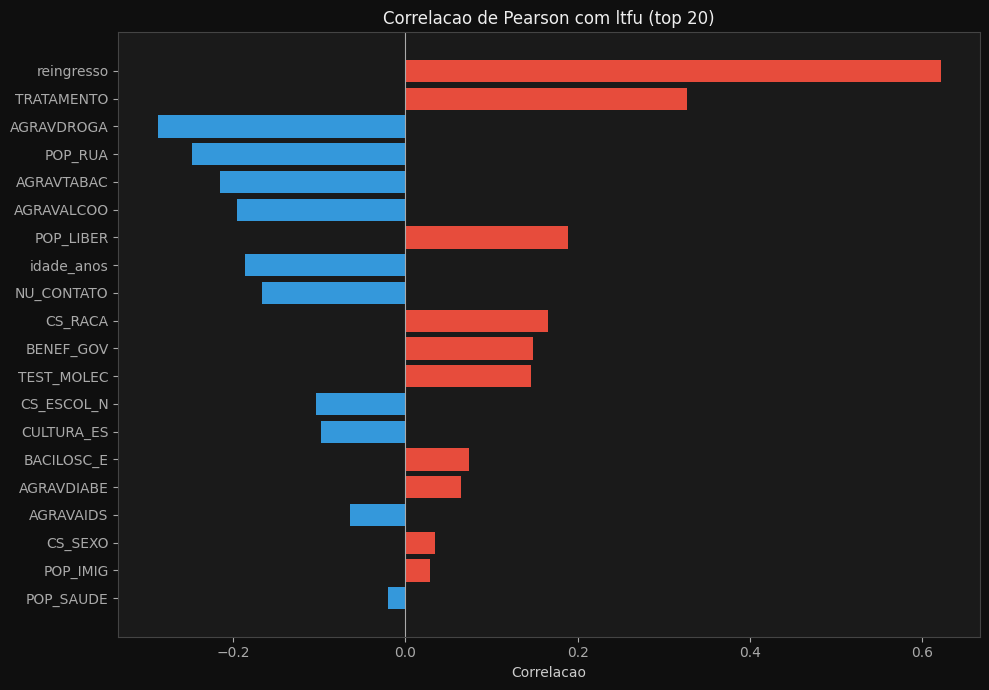

In [7]:
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.facecolor':'#0f0f0f','axes.facecolor':'#1a1a1a',
    'axes.edgecolor':'#444','axes.labelcolor':'#ccc','xtick.color':'#aaa',
    'ytick.color':'#aaa','text.color':'#eee','grid.color':'#333','grid.alpha':0.5})

# Codificar categoricas para correlacao
X_enc = X.copy()
y = df[TARGET]
for col in cat_cols:
    if col in X_enc.columns:
        codes = pd.Categorical(X_enc[col].astype(str)).codes.astype(float)
    codes[codes == -1] = np.nan
    X_enc[col] = codes

corr = X_enc.corrwith(y).dropna().sort_values(key=abs, ascending=False)
print('Top 15 correlacoes com ltfu:')
print(corr.head(15).round(3).to_string())

fig, ax = plt.subplots(figsize=(10,7))
top = corr.head(20)
colors = ['#e74c3c' if v > 0 else '#3498db' for v in top.values]
ax.barh(top.index[::-1], top.values[::-1], color=colors[::-1])
ax.axvline(0, color='#aaa', linewidth=0.8)
ax.set_title('Correlacao de Pearson com ltfu (top 20)')
ax.set_xlabel('Correlacao')
plt.tight_layout()
plt.show()


## 7. Seleção Estatística — LASSO (Regularizacao L1)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Preparar X_lasso com imputacao simples para rodar LASSO
X_lasso = X_enc.copy()
imp = SimpleImputer(strategy='most_frequent')
X_lasso_imp = imp.fit_transform(X_lasso[corr.index])
scaler = RobustScaler()
X_lasso_sc = scaler.fit_transform(X_lasso_imp)

lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, max_iter=1000, random_state=42)
lasso.fit(X_lasso_sc, y)

coef_df = pd.DataFrame({'feature': corr.index, 'coef': lasso.coef_[0]})
coef_df = coef_df[coef_df['coef'] != 0].sort_values('coef', key=abs, ascending=False)
print(f'Features selecionadas pelo LASSO: {len(coef_df)}')
print(coef_df.to_string(index=False))

SELECTED_FEATURES = coef_df['feature'].tolist()


Features selecionadas pelo LASSO: 4
   feature      coef
reingresso  0.991596
TRATAMENTO  0.281682
NU_CONTATO -0.188442
idade_anos -0.045177


## 8. Pipeline Sklearn — RobustScaler + Encoders + IterativeImputer

In [9]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Filtrar apenas features selecionadas pelo LASSO que existem
feat_num = [f for f in SELECTED_FEATURES if f in NUM_COLS]
feat_ord = [f for f in SELECTED_FEATURES if f in ORD_COLS]
feat_nom = [f for f in SELECTED_FEATURES if f in (BIN_COLS + NOM_COLS)]

print('Features numericas no pipeline:', feat_num)
print('Features ordinais no pipeline:', feat_ord)
print('Features nominais no pipeline:', feat_nom)

# Sub-pipelines
num_pipe = Pipeline([
    ('imputer', IterativeImputer(max_iter=10, random_state=42)),
    ('scaler', RobustScaler())
])

ord_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

nom_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

transformers = []
if feat_num: transformers.append(('num', num_pipe, feat_num))
if feat_ord: transformers.append(('ord', ord_pipe, feat_ord))
if feat_nom: transformers.append(('nom', nom_pipe, feat_nom))

preprocessor = ColumnTransformer(transformers=transformers, remainder='drop')

full_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])

print('Pipeline construido com sucesso!')
print(full_pipeline)


Features numericas no pipeline: ['NU_CONTATO', 'idade_anos']
Features ordinais no pipeline: []
Features nominais no pipeline: ['reingresso', 'TRATAMENTO']
Pipeline construido com sucesso!
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   IterativeImputer(random_state=42)),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['NU_CONTATO', 'idade_anos']),
                                                 ('nom',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                       

## 9. Validação Cruzada — Baseline do Modelo

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

X_pipe = X[SELECTED_FEATURES].copy()
# Substituir 9 por NaN nas colunas nominais
for col in feat_nom:
    if col in X_pipe.columns:
        X_pipe[col] = X_pipe[col].astype(str)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(full_pipeline, X_pipe, y, cv=cv,
                          scoring='roc_auc', error_score='raise')

print(f'ROC-AUC por fold: {scores.round(3)}')
print(f'Media: {scores.mean():.3f} +/- {scores.std():.3f}')
print()
scores_f1 = cross_val_score(full_pipeline, X_pipe, y, cv=cv,
                              scoring='f1', error_score='raise')
print(f'F1 por fold:      {scores_f1.round(3)}')
print(f'Media: {scores_f1.mean():.3f} +/- {scores_f1.std():.3f}')


ROC-AUC por fold: [0.657 0.816 0.882 0.818 0.941]
Media: 0.823 +/- 0.095

F1 por fold:      [0.56  0.812 0.733 0.811 0.857]
Media: 0.755 +/- 0.105


## 10. Salvar Dataset Processado e Pipeline

In [11]:
import pickle, os

os.makedirs('data/processed', exist_ok=True)

# Salvar pipeline
with open('data/processed/pipeline.pkl', 'wb') as f:
    pickle.dump(full_pipeline, f)
print('Pipeline salvo em data/processed/pipeline.pkl')

# Salvar dataset pre-processado (antes do pipeline sklearn)
X_save = X[SELECTED_FEATURES].copy()
X_save['ltfu'] = y.values
X_save.to_csv('data/processed/features_selecionadas.csv', index=False)
print(f'Dataset salvo em data/processed/features_selecionadas.csv')
print(f'Shape final: {X_save.shape}')
print(f'Features: {SELECTED_FEATURES}')


Pipeline salvo em data/processed/pipeline.pkl
Dataset salvo em data/processed/features_selecionadas.csv
Shape final: (166, 5)
Features: ['reingresso', 'TRATAMENTO', 'NU_CONTATO', 'idade_anos']


## Resumo

| Etapa | Resultado |
|-------|-----------|
| Filtros aplicados | idade>=18, FORMA=pulmonar, SITUA_ENCE in {1,2} |
| Colunas removidas | 100% nulas + leakage + admin |
| Features criadas | `reingresso`, `dias_notif_trat`, `idade_anos` |
| Valor 9 (ignorado SINAN) | Substituido por NaN |
| Classes raras | Agrupadas em 'OUTRO' (threshold 5%) |
| Selecao Pearson | Top correlacoes identificadas |
| Selecao LASSO | Features com coef != 0 mantidas |
| Encoding | RobustScaler + OrdinalEncoder + OneHotEncoder |
| Imputacao | IterativeImputer (num) + most_frequent (cat) |
| Baseline CV | Ver celula 9 |
